# 4. Image Convolution

## Equipo 22

### Integrantes
 - Erick Alan Cuéllar Quintanilla
 - Fanny Betsabé Fuentes Reyes
 - David Felipe Hernández Chiapa
 - José Emmanuel Vázquez Galán

## Table of Contents
1. [Libraries](#libraries)
2. [Simple Example](#simple)
3. [PyTorch Convolution](#pytorch)

## Importing Libraries <a class="anchor" id="libraries" ></a>

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

## Simple Convolution <a class="anchor" id="simple" ></a>

### Definition

- __I__: Image to convolve.
- __H__: filter matrix to convolve the image with.
- __J__: Result of the convolution.

The following graphics shows exemplary the mathematical operations of the convolution. The filter matrix __H__ is shifted over the input image __I__. The values 'under' the filter matrix are multiplicated with the corresponding values in __H__, summed up and writen to the result __J__. The target position is usually the position under the center of __H__.

<img src="data/convolution.png" width="70%">

In order to implement the convolution with a block filter, we need two methods. The first one will create the block filter matrix __H__ depending on the filter width/height __n__. 

A block filter holds the value $\dfrac{1}{n\cdot n}$ at each position:

In [2]:
def block_filter(n):
    H = np.ones((n, n)) / (n * n) # each element in H has the value 1/(n*n)
    return H

We will test the method by creating a filter with ``n = 5``:

In [3]:
H = block_filter(5)
print(H)

[[0.04 0.04 0.04 0.04 0.04]
 [0.04 0.04 0.04 0.04 0.04]
 [0.04 0.04 0.04 0.04 0.04]
 [0.04 0.04 0.04 0.04 0.04]
 [0.04 0.04 0.04 0.04 0.04]]


Next, we define the actual convolution operation. To prevent invalid indices at the border of the image, we introduce the padding __p__.

In [4]:
def apply_filter(I, H):
    h, w = I.shape                         # image dimensions (height, width)
    n = H.shape[0]                         # filter size
    p = n // 2                             # padding size
    J = np.zeros_like(I)                   # output image, initialized with zeros
    
    for x in range(p, h-p):
        for y in range(p, w-p):
            J[x, y] = np.sum(I[x-p:x+n-p, y-p:y+n-p] * H)
    return J

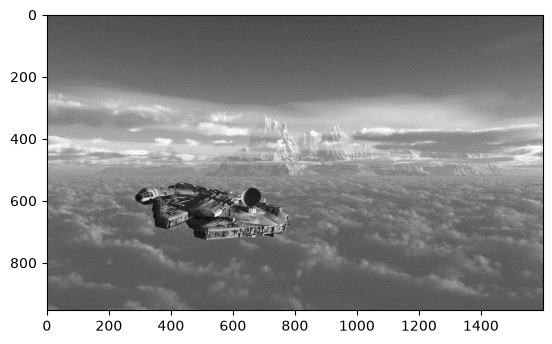

In [5]:
image = Image.open('data/img2.jpg')
image = image.convert('1') # convert image to black and white

image = np.array(image)

# image = np.zeros((200, 200), dtype=np.float)
# for x in range(200):
#     for y in range(200):
#         d = ((x-100)**2+(y-100)**2)**0.5
#         image[x, y] = d % 8 < 4

plt.imshow(image, cmap='gray',vmin=0.0, vmax=1.0)
plt.show()

In [6]:
image = image.astype(float)

Next we test our implementation and apply a block filter with size 7

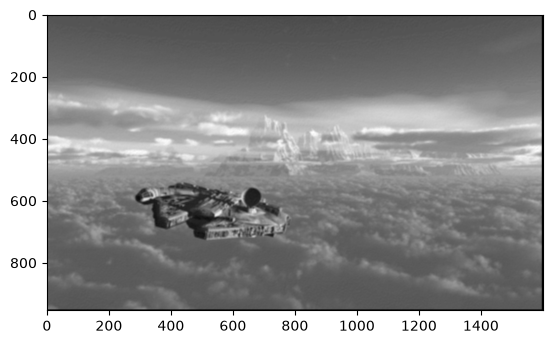

In [7]:
n = 7
H = block_filter(n)
J = apply_filter(image, H)

plt.imshow(J, cmap='gray')
plt.show()

## PyTorch Convolution <a class="anchor" id="pytorch" ></a>

In [8]:
from PIL import Image

img = Image.open('data/img3.jpg')

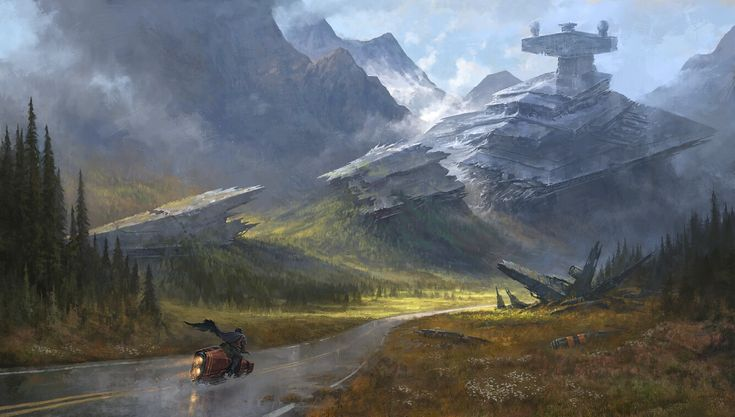

In [9]:
img

In [10]:
import torch, torchvision
from torchvision import transforms
from torch import nn

In [11]:
to_tensor = transforms.Compose([
   transforms.Grayscale(),  # Convert image to grayscale.
   transforms.ToTensor()    # Converts a PIL Image in the range [0, 255] to a torch.FloatTensor in the range [0.0, 1.0].
])

to_pil = transforms.Compose([
    transforms.ToPILImage()
])

In [12]:
input = to_tensor(img)
input.shape


torch.Size([1, 417, 735])

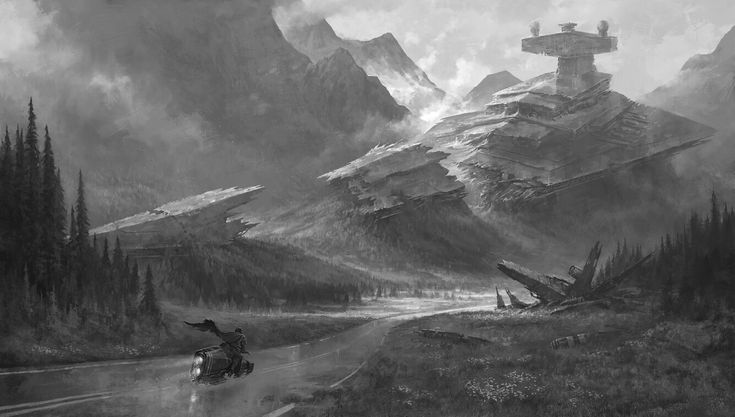

In [13]:
to_pil(input)

2D convolution over an input image:

+ `in_channels = 1`: an input is a grayscale image
+ `out_channels = 1`: an output is a grayscale image
+ `kernel_size = (3, 3)`: the kernel (filter) size is 3 x 3
+ `stride = 1`: the stride for the cross-correlation is 1
+ `padding = 1`: zero-paddings on both sides for 1 point for each dimension
+ `bias = False`: no bias parameter (for simplicity)

In [14]:
conv = nn.Conv2d(1, 1, (3, 3), stride=1, padding=1, bias=False)

In [ ]:
# The code below does not work because the convolution layer requires the dimension for batch.
conv(input)

We need to insert a dimension for a batch at dim=0.

In [15]:
input = input.unsqueeze(0)
input.shape

torch.Size([1, 1, 417, 735])

In [16]:
output = conv(input)
output.shape

torch.Size([1, 1, 417, 735])

Setting `padding=1` in the convolution layer, we obtain an image of the same size.

In [17]:
output.shape

torch.Size([1, 1, 417, 735])

We need to remove the first dimension before converting to a PIL object.

In [18]:
output.data.squeeze(dim=0).shape

torch.Size([1, 417, 735])

Display the output from the convolution layer by converting `output` to a PIL object.

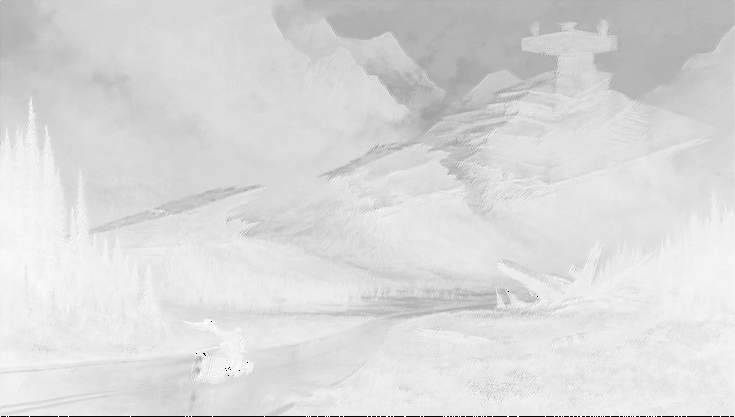

In [19]:
to_pil(output.data.squeeze(dim=0))

Clip every value in the output tensor within the range of [0, 1].

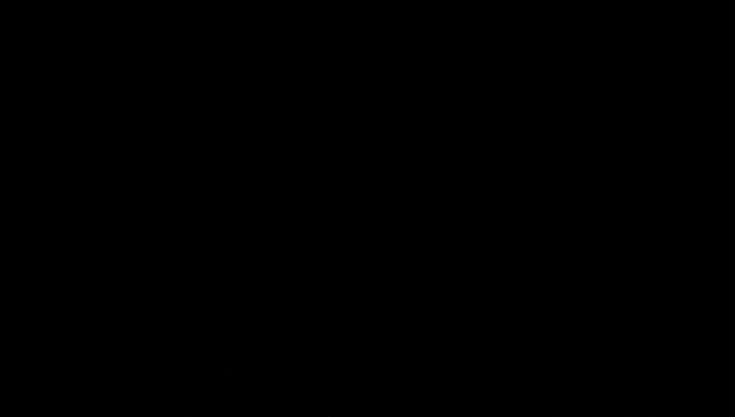

In [20]:
to_pil(torch.clamp(output, 0, 1).data.squeeze(dim=0))

In [21]:
def display(img1, img2):
    im1 = to_pil(torch.clamp(img1, 0, 1).data.squeeze(dim=0))
    im2 = to_pil(torch.clamp(img2, 0, 1).data.squeeze(dim=0))
    dst = Image.new('RGB', (im1.width + im2.width, im1.height))
    dst.paste(im1, (0, 0))
    dst.paste(im2, (im1.width, 0))
    return dst

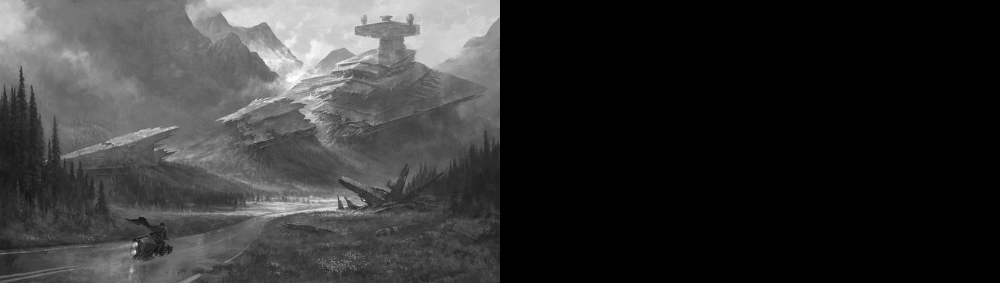

In [22]:
display(input, output)

### Identity

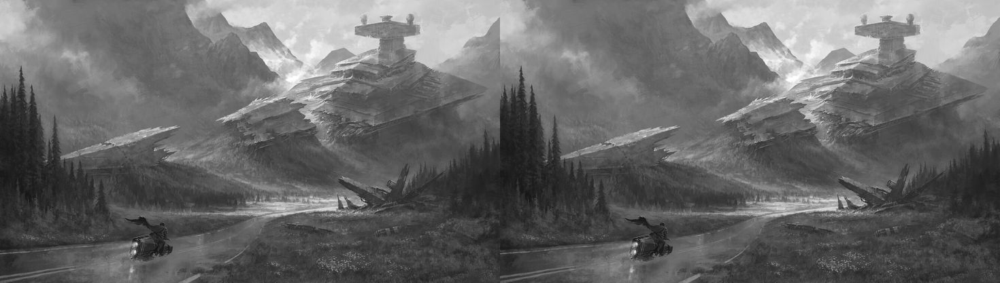

In [23]:
conv.weight.data = torch.tensor([[[
    [0., 0., 0.],
    [0., 1, 0.],
    [0., 0., 0.],
]]])

output = conv(input)
display(input, output)

### Brighten

tensor([[[[0.0000, 0.0000, 0.0000],
          [0.0000, 1.5000, 0.0000],
          [0.0000, 0.0000, 0.0000]]]])


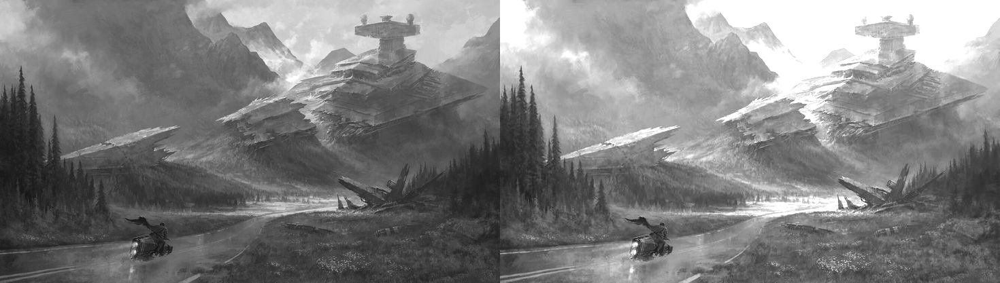

In [24]:
conv.weight.data = torch.tensor([[[
    [0., 0., 0.],
    [0., 1.5, 0.],
    [0., 0., 0.],
]]])
print(conv.weight.data)
output = conv(input)
display(input, output)

### Darken

tensor([[[[0.0000, 0.0000, 0.0000],
          [0.0000, 0.5000, 0.0000],
          [0.0000, 0.0000, 0.0000]]]])


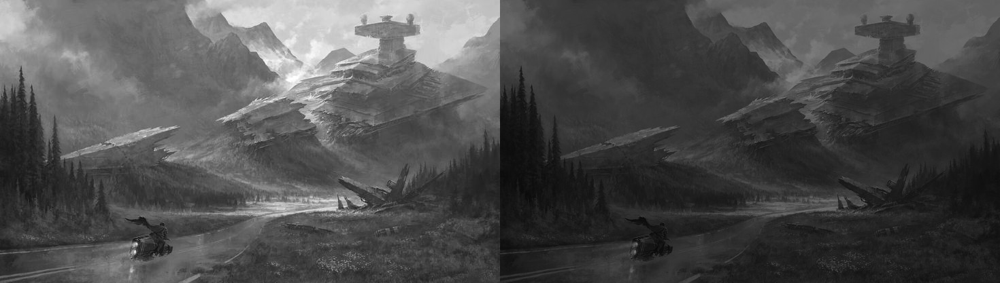

In [25]:
conv.weight.data = torch.tensor([[[
    [0., 0., 0.],
    [0., 0.5, 0.],
    [0., 0., 0.],
]]])
print(conv.weight.data)
output = conv(input)
display(input, output)

### Box blur

tensor([[[[0.1111, 0.1111, 0.1111],
          [0.1111, 0.1111, 0.1111],
          [0.1111, 0.1111, 0.1111]]]])


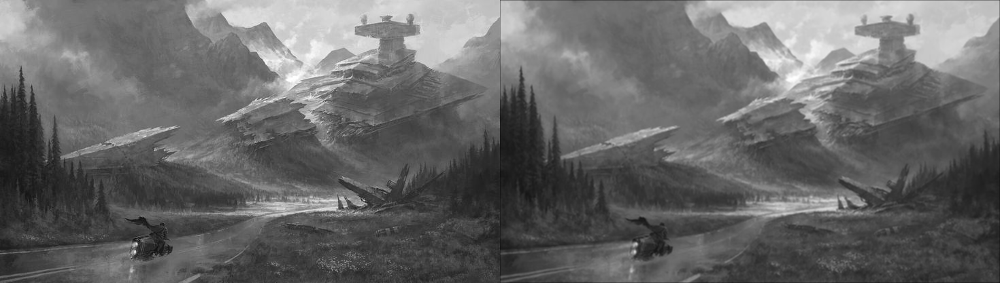

In [26]:
conv.weight.data = torch.ones((1, 1, 3,3), dtype=torch.float) / 9.
print(conv.weight.data)
output = conv(input)
display(input, output)

### Gaussian blur

tensor([[[[0.0625, 0.1250, 0.0625],
          [0.1250, 0.2500, 0.1250],
          [0.0625, 0.1250, 0.0625]]]])


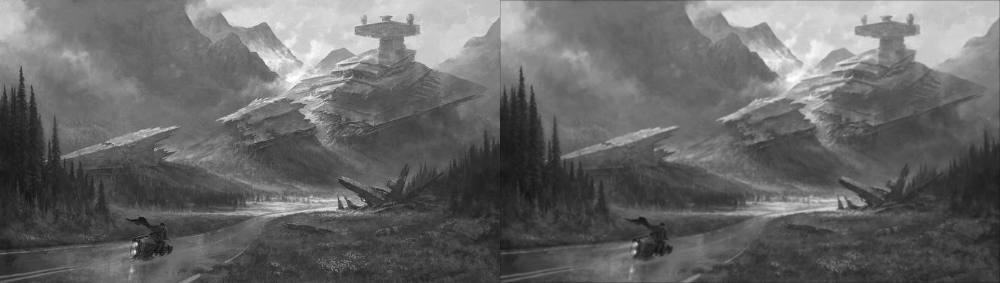

In [27]:
conv.weight.data = torch.tensor([[[
    [1., 2., 1.],
    [2., 4., 2.],
    [1., 2., 1.],
]]])/16.
print(conv.weight.data)
output = conv(input)
display(input, output)

### Sharpen

tensor([[[[ 0., -1.,  0.],
          [-1.,  5., -1.],
          [ 0., -1.,  0.]]]])


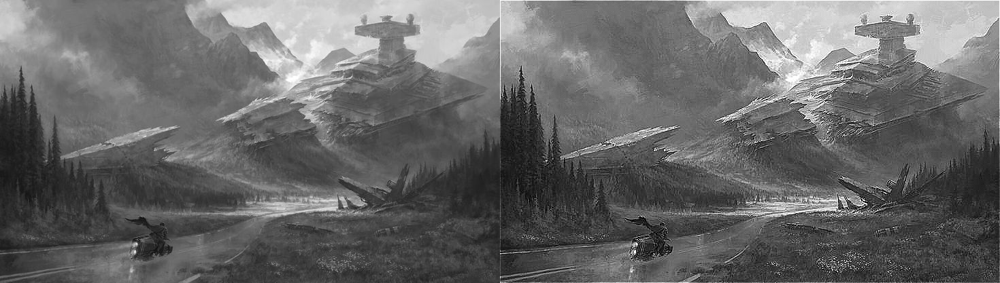

In [28]:
conv.weight.data = torch.tensor([[[
    [0., -1., 0.],
    [-1., 5., -1.],
    [0., -1., 0.],
]]])
print(conv.weight.data)
output = conv(input)
display(input, output)

tensor([[[[ 0., -2.,  0.],
          [-2., 10., -2.],
          [ 0., -2.,  0.]]]])


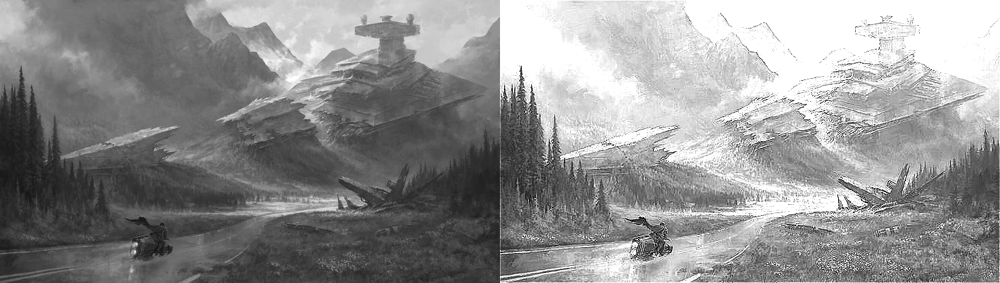

In [29]:
conv.weight.data = torch.tensor([[[
    [0., -2., 0.],
    [-2., 10., -2.],
    [0., -2., 0.],
]]])
print(conv.weight.data)
output = conv(input)
display(input, output)

### Edge detection

tensor([[[[ 0.,  1.,  0.],
          [ 1., -4.,  1.],
          [ 0.,  1.,  0.]]]])


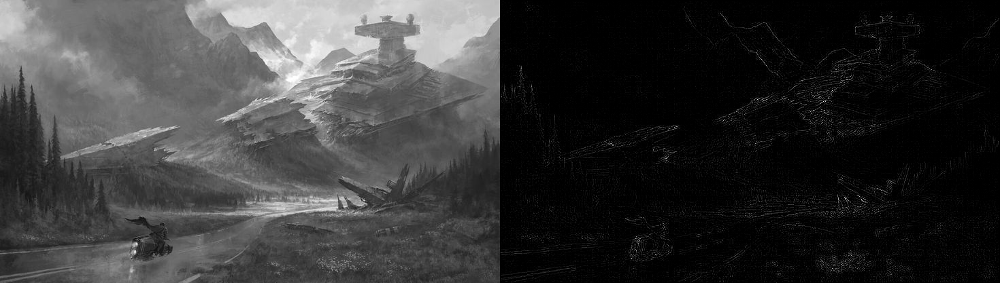

In [30]:
conv.weight.data = torch.tensor([[[
    [0., 1., 0.],
    [1., -4., 1.],
    [0., 1., 0.],
]]])
print(conv.weight.data)
output = conv(input)
display(input, output)

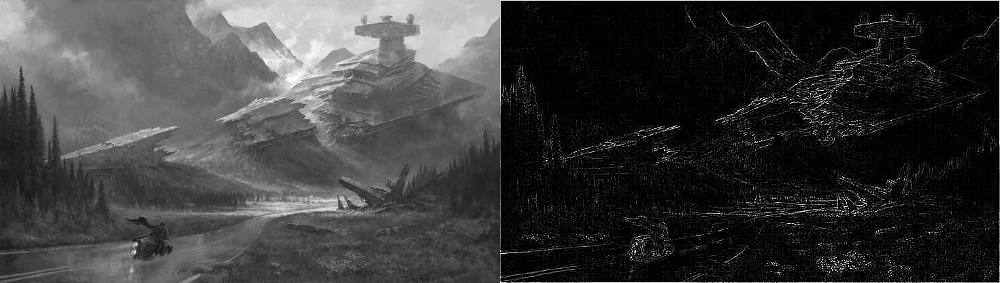

In [31]:
conv.weight.data = torch.tensor([[[
    [-1., -1., -1.],
    [-1., 8., -1.],
    [-1., -1., -1.],
]]])
output = conv(input)
display(input, output)

## Algoritmos de mejoramiento de imágenes en el dominio espacial

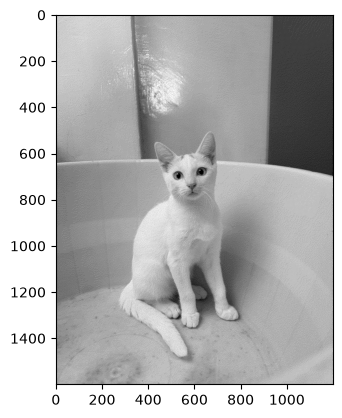

In [40]:
image = Image.open('data/gato2.jpeg')
image = image.convert('1') # convert image to black and white

image = np.array(image)

plt.imshow(image, cmap='gray',vmin=0.0, vmax=1.0)
plt.show()

### 1. Implementa los detectores de línea siguientes usando código en Python (es decir, sin usar librerías de OpenCV): Prewitt, Sobel y Laplaciano. Investiga la complejidad algoritmica de estos, ¿cual es más eficiente?

#### Prewitt

El filtro Prewitt calcula los cambios de intensidad horizontal y vertical mediante dos máscaras de 3×3. Al combinar ambas respuestas se obtiene la magnitud del gradiente, que resalta los bordes en la imagen. Es sencillo, pero puede ser sensible al ruido.

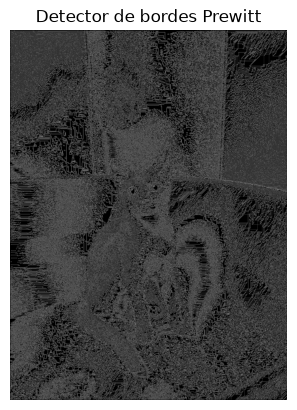

In [50]:
prewitt_x = np.array([[-1, 0, 1],
                      [-1, 0, 1],
                      [-1, 0, 1]], dtype=float)
prewitt_y = prewitt_x.T

original = image.astype(float)

respuesta_x = apply_filter(original, prewitt_x)
respuesta_y = apply_filter(original, prewitt_y)
prewitt = np.hypot(respuesta_x, respuesta_y)

# Normalización para visualizar el resultado.
if prewitt.max() > 0:
    prewitt = prewitt / prewitt.max()

plt.imshow(prewitt, cmap="gray", vmin=0, vmax=1)
plt.title("Detector de bordes Prewitt")
plt.axis("off")
plt.show()

#### Sobel
El filtro Sobel también calcula gradientes horizontal y vertical con máscaras de 3×3. Da mayor peso a los píxeles centrales de cada máscara, lo que aporta cierto suavizado y suele hacerlo menos sensible al ruido que Prewitt. La combinación de las dos respuestas muestra la intensidad de los bordes.

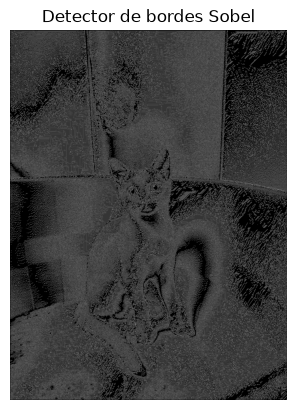

In [49]:
sobel_x = np.array([[-1, 0, 1],
                    [-2, 0, 2],
                    [-1, 0, 1]], dtype=float)
sobel_y = sobel_x.T

original = image.astype(float)

respuesta_x = apply_filter(original, sobel_x)
respuesta_y = apply_filter(original, sobel_y)
sobel = np.hypot(respuesta_x, respuesta_y)

# Normalización para visualizar el resultado.
if sobel.max() > 0:
    sobel = sobel / sobel.max()

plt.imshow(sobel, cmap="gray", vmin=0, vmax=1)
plt.title("Detector de bordes Sobel")
plt.axis("off")
plt.show()

#### Laplaciano

El filtro Laplaciano usa una máscara que aproxima la segunda derivada de la imagen. Resalta cambios bruscos de intensidad sin separar los bordes por dirección. Es rápido porque aplica una sola máscara, pero puede amplificar el ruido; por eso, a menudo se aplica después de suavizar la imagen.

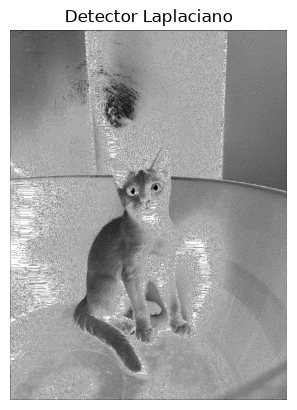

In [ ]:
laplaciano_kernel = np.array([[0,  1, 0],
                              [1, -4, 1],
                              [0,  1, 0]], dtype=float)

original = image.astype(float)
if original.max() > 1:
    original /= 255.0

laplaciano = np.abs(apply_filter(original, laplaciano_kernel))

# Normalización para visualizar el resultado.
if laplaciano.max() > 0:
    laplaciano = laplaciano / laplaciano.max()

plt.imshow(laplaciano, cmap="gray", vmin=0, vmax=1)
plt.title("Detector Laplaciano")
plt.axis("off")
plt.show()

Los tres filtros recorren numero constante de veces las imagenes con filtros de 3X3 entonces, la complejidad es la misma para los 3, i.e., $O(H \times W)$. Sin embargo, como la notacion de $O()$ no considera las constantes, el Laplaciano al solamente recorrer la imagen una vez con un solo filtro, podria ser considerado mas eficiente.

### 2. Implementa un algoritmos de realce o mejoramiento de imágenes mediante un algoritmo de en el cual se extraen las líneas de la imagen y después se aplica la diferencia con la imagen original, multiplicando los píxeles de la imagen “máscara” (las líneas encontradas) por un factor alfa mayor a 1.

El realce se realiza con el Laplaciano. Primero se obtiene su respuesta, que resalta los cambios de intensidad. Después se resta esa respuesta, multiplicada por α > 1, a la imagen original: $g(x,y) = f(x,y) − αf(x,y)$. Para visualizar las líneas se muestra el valor absoluto de la respuesta; para el realce se conserva su signo.

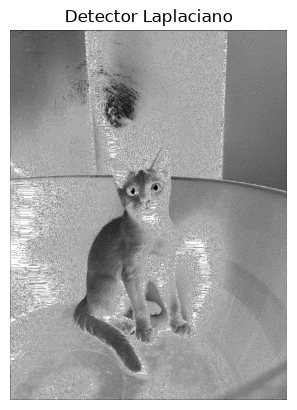

In [52]:
# Convertir a float antes de filtrar.
original = image.astype(float)
if original.max() > 1:
    original /= 255.0

# Aplicando Laplaciano.
laplaciano = np.abs(apply_filter(original, laplaciano_kernel))

# Normalización para visualizar el resultado.
if laplaciano.max() > 0:
    laplaciano = laplaciano / laplaciano.max()

plt.imshow(laplaciano, cmap="gray", vmin=0, vmax=1)
plt.title("Detector Laplaciano")
plt.axis("off")
plt.show()

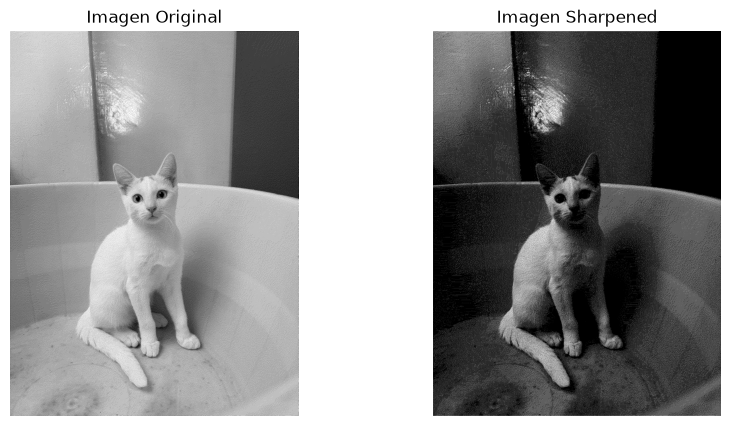

In [62]:
alpha = 1.5
sharpened = np.clip(original - alpha * laplaciano, 0, 1)
# mostrar original y sharpened en un mismo gráfico
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(original, cmap="gray", vmin=0, vmax=1)
plt.title("Imagen Original")
plt.axis("off")
plt.subplot(1, 2, 2)
plt.imshow(sharpened, cmap="gray", vmin=0, vmax=1)
plt.title("Imagen Sharpened")
plt.axis("off")
plt.show()

### 3. Buscar una aplicación médica (en el libro de Gonzalez viene varios ejemplos de imágenes PET) y hacer mejoramiento usando la técnica de de la Figura 3.43 combinando diferentes etapas de procesamiento de imagenes


Se toma como imagen de entrada una imagen PET frontal (Otorgada por el alumno David Hernandez). Siguiendo como referencia el flujo de procesamiento de la Figura 3.43 de Gonzalez y Woods, se comparan dos métodos de reducción de ruido:

- **(a) Original:** imagen PET frontal sin filtrar.
- **(b) Gaussian lowpass filter:** de 19 × 19 píxeles con $\sigma=3$. Suaviza la imagen y atenúa variaciones de alta frecuencia.
- **(c) Median filter:** de 7 × 7 píxeles. Reemplaza cada píxel por la mediana de los valores de su vecindad y puede reducir ruido impulsivo conservando algunos bordes.

La figura del libro aplica estas operaciones a una imagen de rayos X; aquí se reutiliza la secuencia de procesamiento con una imagen PET frontal. Se comparan los resultados visualmente para observar cómo cada filtro modifica el ruido y los detalles de la imagen. Este ejemplo es únicamente de procesamiento y no tiene propósito diagnóstico.



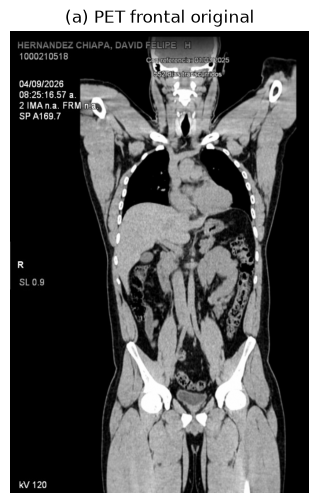

In [ ]:
# Original
pet_path = "data/PET-Frontal.jpeg"

pet = Image.open(pet_path).convert("L")
pet = np.asarray(pet, dtype=float) / 255.0

plt.figure(figsize=(6, 6))
plt.imshow(pet, cmap="gray", vmin=0, vmax=1)
plt.title("(a) PET frontal original")
plt.axis("off")
plt.show()

# Aplica apply_filter con padding reflect para evitar bordes negros artificiales.
def apply_filter_reflect(I, H):
    padding = H.shape[0] // 2
    padded = np.pad(I, ((padding, padding), (padding, padding)), mode="reflect")
    filtered = apply_filter(padded, H)
    return filtered[padding:-padding, padding:-padding]

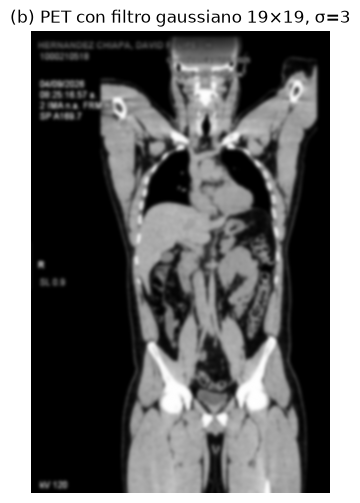

In [65]:
size = 19
sigma = 3

coords = np.arange(-(size // 2), size // 2 + 1)
x, y = np.meshgrid(coords, coords)

gaussian_kernel = np.exp(-(x**2 + y**2) / (2 * sigma**2))
gaussian_kernel /= gaussian_kernel.sum()

pet_gaussian = apply_filter_reflect(pet, gaussian_kernel)

plt.figure(figsize=(6, 6))
plt.imshow(pet_gaussian, cmap="gray", vmin=0, vmax=1)
plt.title("(b) PET con filtro gaussiano 19×19, σ=3")
plt.axis("off")
plt.show()

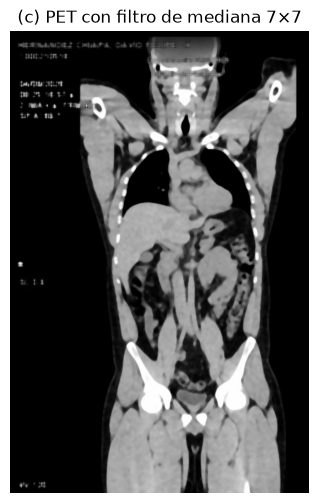

In [66]:
size = 7
padding = size // 2

pet_padded = np.pad(pet, ((padding, padding), (padding, padding)), mode="reflect")
windows = np.lib.stride_tricks.sliding_window_view(
    pet_padded, (size, size)
)
pet_median = np.median(windows, axis=(-2, -1))

plt.figure(figsize=(6, 6))
plt.imshow(pet_median, cmap="gray", vmin=0, vmax=1)
plt.title("(c) PET con filtro de mediana 7×7")
plt.axis("off")
plt.show()

## Referencias
 
Gonzalez, R. C., & Woods, R. E. *Digital Image Processing*, 4.ª ed., Pearson.